# LSTM - SAFEX white maize with external drivers

A stacked LSTM that looks at the previous `WINDOW` business days of **price, ZAR/USD, rainfall and fuel
price** and predicts the next day's SAFEX white maize price.

What changed compared with the soybean version:

* the input is now **multivariate** (price + external drivers) instead of the price alone
* the old `fastai` date features, tweet-sentiment lags and unused XGBoost / scikit-learn imports are gone
* `keras` imports now come from `tensorflow.keras`
* the scaler is fitted on the **training block only**, then applied to the test block
* early stopping on a validation slice replaces blindly running all 150 epochs
* a **univariate LSTM** (price only) is trained as well, so you can see whether the drivers help

Predictions are **one-step-ahead**: each test day is predicted from the previous `WINDOW` actual days.

## 1. Imports

In [4]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
tf.keras.utils.set_random_seed(42)
%matplotlib inline

## 2. Load and align the datasets

In [5]:
# ---- Data settings ---------------------------------------------------------
PRICES_FILE = 'safex_prices.csv'   # Date, Close (R/ton)  [+ optional Open, High, Low, Volume]
EXOG_FILE   = 'sa_factors.csv'     # Date, ZAR_USD, Rainfall_mm, Fuel_Price
TARGET_COL  = 'Close'              # SAFEX white maize price column
EXOG_COLS   = ['ZAR_USD', 'Rainfall_mm', 'Fuel_Price']   # external drivers
TRAIN_FRAC  = 0.8                  # chronological split: first 80% train, last 20% test

# ---- LSTM settings -------------------------------------------------------------
WINDOW     = 60      # business days of history the network sees (about 3 months)
EPOCHS     = 150     # upper limit - early stopping usually ends training sooner
BATCH_SIZE = 16
UNITS      = 50

In [6]:
# Load the SAFEX white maize prices and the South African external drivers.
# (If your dates are written dd/mm/yyyy, add dayfirst=True to both read_csv calls.)
prices = pd.read_csv(PRICES_FILE, parse_dates=['Date'], index_col='Date')
exog_data = pd.read_csv(EXOG_FILE, parse_dates=['Date'], index_col='Date')

# Tidy up: ascending dates and no duplicated dates
prices = prices.sort_index()
prices = prices[~prices.index.duplicated(keep='last')]
exog_data = exog_data.sort_index()
exog_data = exog_data[~exog_data.index.duplicated(keep='last')]

# Fail early, with a readable message, if a column name does not match the settings above
missing = [c for c in [TARGET_COL] if c not in prices.columns] + \
          [c for c in EXOG_COLS if c not in exog_data.columns]
if missing:
    raise KeyError(f'Column(s) not found in the CSV files: {missing}')

In [7]:
# Safeguard: put lower-frequency drivers (e.g. monthly fuel prices) on a daily calendar BEFORE the
# join, carrying the last known value forward. Otherwise a monthly series only matches ~12 dates a
# year, and the inner join below would silently throw away almost all of the daily price rows.
# (.last().ffill() also fills blanks if all drivers sit in one wide file with empty cells.)
exog_data = exog_data.resample('D').last().ffill()

# Merge both dataframes with an inner join so that the dates align
data = prices.join(exog_data, how='inner')

# Business-day calendar; forward-fill weekend / holiday gaps
data = data.resample('B').ffill()
data = data.dropna(subset=[TARGET_COL] + EXOG_COLS)

In [8]:
print(f'{len(data)} business days   {data.index.min().date()} -> {data.index.max().date()}')
data[[TARGET_COL] + EXOG_COLS].describe().round(2)

2870 business days   2015-01-01 -> 2025-12-31


,Close,ZAR_USD,Rainfall_mm,Fuel_Price
count,2870.00,2870.00,2870.00,2870.00
mean,3589.75,14.52,3.01,16.48
std,669.46,1.90,6.69,1.52
min,2478.00,11.33,0.00,12.35
25%,3090.00,12.93,0.00,15.77
50%,3547.50,14.28,0.00,16.90
75%,3869.75,15.97,2.50,17.74
max,5763.00,18.73,54.90,18.89


## 3. Train / test split (chronological)

In [9]:
# Target variable (y) and external drivers (X)
y = data[TARGET_COL]
X = data[EXOG_COLS]

# Chronological split point (80% train / 20% test)
train_size = int(len(data) * TRAIN_FRAC)

# Training sets
y_train = y.iloc[:train_size]
X_train = X.iloc[:train_size]

# Testing sets
y_test = y.iloc[train_size:]
X_test = X.iloc[train_size:]

print(f'train: {len(y_train)} days  ({y_train.index.min().date()} -> {y_train.index.max().date()})')
print(f'test : {len(y_test)} days  ({y_test.index.min().date()} -> {y_test.index.max().date()})')

train: 2296 days  (2015-01-01 -> 2023-10-19)
test : 574 days  (2023-10-20 -> 2025-12-31)


## 4. Windows and model

`make_windows` turns the table into samples: the previous `WINDOW` days of every feature (rows
*i - WINDOW ... i - 1*) are the input and the price on day *i* is the target. Test windows reach back into the
training period for their history, exactly like the original notebook (which fed the 60 days before the
test block).

In [10]:
def make_windows(features, target, window):
    """features: (n, n_features) array, target: (n,) array -> samples, targets, target row index."""
    X_w, y_w, target_idx = [], [], []
    for i in range(window, len(features)):
        X_w.append(features[i - window:i])
        y_w.append(target[i])
        target_idx.append(i)
    return np.array(X_w), np.array(y_w), np.array(target_idx)

In [11]:
def run_lstm(columns, window=WINDOW, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=42):
    """Train an LSTM on `columns` (the target column must come first) and
    return its one-step-ahead predictions for the test block."""
    tf.keras.utils.set_random_seed(seed)

    feats = data[columns]
    feat_scaler = MinMaxScaler(feature_range=(0, 1)).fit(feats.iloc[:train_size])          # TRAIN only
    tgt_scaler = MinMaxScaler(feature_range=(0, 1)).fit(y.iloc[:train_size].to_numpy().reshape(-1, 1))
    scaled_feats = feat_scaler.transform(feats)
    scaled_tgt = tgt_scaler.transform(y.to_numpy().reshape(-1, 1)).ravel()

    X_w, y_w, idx = make_windows(scaled_feats, scaled_tgt, window)
    is_train = idx < train_size

    # create and fit the LSTM network
    model = Sequential([
        Input(shape=(window, len(columns))),
        LSTM(units=UNITS, return_sequences=True),
        Dropout(0.2),
        LSTM(units=UNITS),
        Dropout(0.2),
        Dense(1),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(X_w[is_train], y_w[is_train], epochs=epochs, batch_size=batch_size,
                        validation_split=0.1,          # the LAST 10% of the training windows
                        callbacks=[early_stop], verbose=2)

    pred_scaled = model.predict(X_w[~is_train], verbose=0)
    pred = pd.Series(tgt_scaler.inverse_transform(pred_scaled).ravel(),
                     index=y.index[idx[~is_train]])
    return {'model': model, 'history': history, 'pred': pred,
            'tgt_scaler': tgt_scaler, 'scaled_feats': scaled_feats}

## 5. Train the models

In [12]:
# LSTM with the external drivers: price + ZAR/USD + rainfall + fuel price
lstm_exog = run_lstm([TARGET_COL] + EXOG_COLS)

Epoch 1/150


E0000 00:00:1791032051.096362    5352 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


126/126 - 4s - 32ms/step - loss: 0.0068 - val_loss: 0.0019
Epoch 2/150
126/126 - 1s - 12ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 3/150
126/126 - 2s - 14ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 4/150
126/126 - 1s - 11ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 5/150
126/126 - 2s - 15ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 6/150
126/126 - 2s - 14ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 7/150
126/126 - 2s - 13ms/step - loss: 9.3087e-04 - val_loss: 0.0012
Epoch 8/150
126/126 - 1s - 11ms/step - loss: 9.6754e-04 - val_loss: 0.0020
Epoch 9/150
126/126 - 2s - 15ms/step - loss: 8.5892e-04 - val_loss: 0.0037
Epoch 10/150
126/126 - 2s - 16ms/step - loss: 7.6862e-04 - val_loss: 0.0014
Epoch 11/150
126/126 - 2s - 16ms/step - loss: 7.3127e-04 - val_loss: 0.0027
Epoch 12/150
126/126 - 2s - 14ms/step - loss: 6.8946e-04 - val_loss: 0.0015
Epoch 13/150
126/126 - 2s - 15ms/step - loss: 6.5493e-04 - val_loss: 0.0023
Epoch 14/150
126/126 - 2s - 14ms/step - loss: 6.3417e-04 

In [13]:
# Reference: LSTM on the price alone (the original design)
lstm_uni = run_lstm([TARGET_COL])

Epoch 1/150
126/126 - 3s - 25ms/step - loss: 0.0045 - val_loss: 0.0014
Epoch 2/150
126/126 - 2s - 12ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/150
126/126 - 2s - 14ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 4/150
126/126 - 2s - 13ms/step - loss: 9.8171e-04 - val_loss: 0.0022
Epoch 5/150
126/126 - 2s - 15ms/step - loss: 8.9912e-04 - val_loss: 9.3571e-04
Epoch 6/150
126/126 - 2s - 15ms/step - loss: 8.2666e-04 - val_loss: 0.0019
Epoch 7/150
126/126 - 2s - 13ms/step - loss: 7.6191e-04 - val_loss: 0.0015
Epoch 8/150
126/126 - 2s - 13ms/step - loss: 7.6948e-04 - val_loss: 0.0024
Epoch 9/150
126/126 - 2s - 13ms/step - loss: 7.0689e-04 - val_loss: 0.0031
Epoch 10/150
126/126 - 2s - 13ms/step - loss: 6.2684e-04 - val_loss: 0.0024
Epoch 11/150
126/126 - 2s - 12ms/step - loss: 5.9703e-04 - val_loss: 0.0021
Epoch 12/150
126/126 - 2s - 13ms/step - loss: 5.5808e-04 - val_loss: 0.0025
Epoch 13/150
126/126 - 2s - 14ms/step - loss: 5.3410e-04 - val_loss: 0.0032
Epoch 14/150
126/126 - 2s - 1

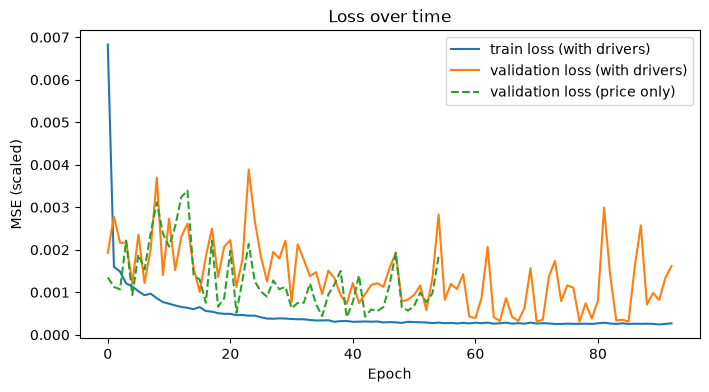

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_exog['history'].history['loss'], label='train loss (with drivers)')
plt.plot(lstm_exog['history'].history['val_loss'], label='validation loss (with drivers)')
plt.plot(lstm_uni['history'].history['val_loss'], label='validation loss (price only)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.title('Loss over time')
plt.legend()
plt.show()

## 6. Evaluate

The original notebook reported only RMSE; here MAE (R/ton), RMSE and MAPE are reported next to a
**naive benchmark** (tomorrow's price = today's price). A model that cannot beat the naive line is not
adding value.

In [15]:
def score(y_true, y_pred):
    """MAE (R/ton), RMSE (R/ton) and MAPE (%)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAPE %': float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)}


actual = y.loc[lstm_exog['pred'].index]            # identical to y_test
results = {
    'LSTM + drivers': score(actual, lstm_exog['pred']),
    'LSTM, price only': score(actual, lstm_uni['pred']),
    'Naive: previous day': score(actual, y.shift(1).loc[actual.index]),
}
pd.DataFrame(results).T.round(2).sort_values('MAE')

,MAE,RMSE,MAPE %
Naive: previous day,36.61,46.14,0.88
"LSTM, price only",39.67,49.85,0.95
LSTM + drivers,43.37,54.01,1.06


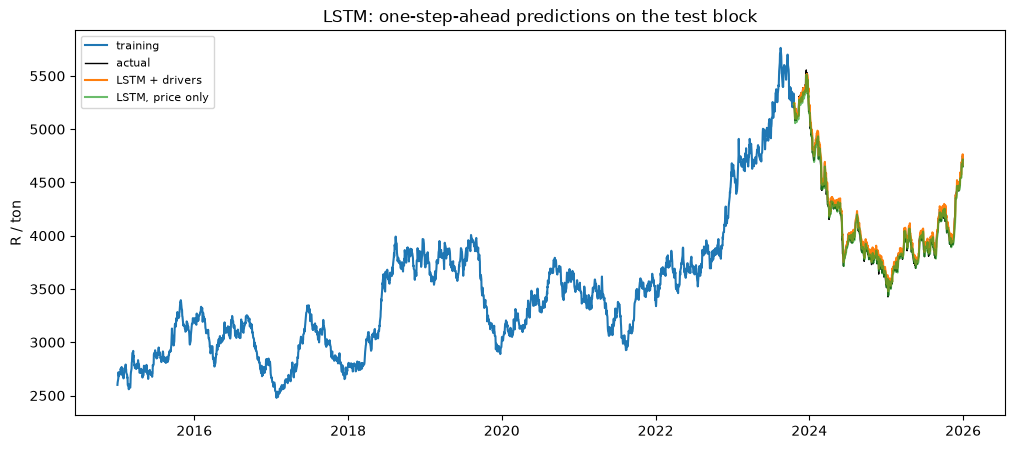

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(y_train, label='training')
plt.plot(actual, label='actual', color='black', linewidth=1)
plt.plot(lstm_exog['pred'], label='LSTM + drivers')
plt.plot(lstm_uni['pred'], label='LSTM, price only', alpha=0.7)
plt.title('LSTM: one-step-ahead predictions on the test block')
plt.ylabel('R / ton')
plt.legend(loc='upper left', fontsize=8)
plt.show()

## 7. Forecast the next business day

The most recent `WINDOW` days (all of them known) are fed to the network.

In [17]:
last_window = lstm_exog['scaled_feats'][-WINDOW:].reshape(1, WINDOW, -1)
next_scaled = lstm_exog['model'].predict(last_window, verbose=0)
next_price = lstm_exog['tgt_scaler'].inverse_transform(next_scaled)[0, 0]
next_date = data.index[-1] + pd.offsets.BDay(1)

print(f'LSTM forecast for {next_date.date()}: R {next_price:,.2f} per ton')

LSTM forecast for 2026-01-01: R 4,641.69 per ton


**Limitations worth knowing.** The scaler is fitted on the training block, so if prices in the test block
climb above anything seen in training, the scaled inputs exceed 1 and the LSTM extrapolates poorly - one
reason XGBoost in this project predicts price *changes*. Neural networks also need a lot of data; with a few
years of daily prices expect results comparable to, not better than, the tree model.